# Localization Decoding Diversity Ablation: Paper-Facing Analysis Notebook

This notebook analyzes the decoding ablation output at:

- `/playpen-ssd/smerrill/deception2/Notebooks/datasetmain_localization_decoding_diversity_outputs/qwen7b_decoding_diversity_mpnet`

It is designed to answer the paper-facing questions directly:

1. Which decoding configuration is most diverse?
2. Which configuration gives the best diversity/verbosity tradeoff?
3. How much do temperature, top-p, and repetition penalty each matter?
4. Are the aggregate patterns reasonably consistent across environments?
5. Which qualitative examples are strongest for illustrating the tradeoff?

By default, everything renders inline and the notebook does **not** write extra files.

In [1]:
from pathlib import Path
import json
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.precision", 3)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

OUTPUT_ROOT = Path(
    "/playpen-ssd/smerrill/deception2/Notebooks/"
    "datasetmain_localization_decoding_diversity_outputs/"
    "qwen7b_decoding_diversity_mpnet"
)
CACHE_DIR = OUTPUT_ROOT / "per_prefix_cache"
SAVE_ARTIFACTS = False
ARTIFACT_DIR = OUTPUT_ROOT / "paper_artifacts_from_notebook"
DEFAULT_QUAL_EXAMPLE_KEY = "AdvisorAudit::2026-03-05/gpu_4/state_641/sample_25"


In [1]:
from pathlib import Path
import json
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.precision", 3)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

OUTPUT_ROOT = Path(
    "/playpen-ssd/smerrill/deception2/Notebooks/"
    "datasetmain_localization_decoding_diversity_outputs/"
    "qwen7b_decoding_diversity_mpnet"
)
CACHE_DIR = OUTPUT_ROOT / "per_prefix_cache"
SAVE_ARTIFACTS = False
ARTIFACT_DIR = OUTPUT_ROOT / "paper_artifacts_from_notebook"
DEFAULT_QUAL_EXAMPLE_KEY = "AdvisorAudit::2026-03-05/gpu_4/state_641/sample_25"


In [2]:
required = {
    "config": OUTPUT_ROOT / "config.csv",
    "candidate_counts": OUTPUT_ROOT / "candidate_counts_by_env.csv",
    "selection_counts": OUTPUT_ROOT / "selection_counts_by_env.csv",
    "selected_prefixes": OUTPUT_ROOT / "selected_prefixes.csv",
    "combo_grid": OUTPUT_ROOT / "combo_grid.csv",
    "per_prefix": OUTPUT_ROOT / "per_prefix_combo_metrics.csv",
}

missing = [name for name, path in required.items() if not path.exists()]
if missing:
    raise FileNotFoundError(f"Missing expected files: {missing}")

config = pd.read_csv(required["config"])
candidate_counts = pd.read_csv(required["candidate_counts"])
selection_counts = pd.read_csv(required["selection_counts"])
selected_prefixes = pd.read_csv(required["selected_prefixes"])
combo_grid = pd.read_csv(required["combo_grid"])
per_prefix = pd.read_csv(required["per_prefix"])

config_map = dict(zip(config["setting"], config["value"]))
candidate_total = int(candidate_counts["short_label_examples"].sum())
selected_total = int(selection_counts["selected_prefixes"].sum())


def combo_tuple(row_or_result):
    return (
        float(row_or_result["temperature"]),
        float(row_or_result["top_p"]),
        float(row_or_result["repetition_penalty"]),
    )


def combo_label(combo):
    temperature, top_p, repetition_penalty = combo
    return f"T={temperature:.1f}, top-p={top_p:.1f}, rep={repetition_penalty:.1f}"


def bootstrap_mean_ci(values, repeats=5000, seed=0):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    sample_idx = rng.integers(0, values.size, size=(repeats, values.size))
    bootstrap_means = values[sample_idx].mean(axis=1)
    return (
        float(values.mean()),
        float(np.quantile(bootstrap_means, 0.025)),
        float(np.quantile(bootstrap_means, 0.975)),
    )


def summarize_combos(per_prefix_df):
    rows = []
    grouped = per_prefix_df.groupby(
        ["temperature", "top_p", "repetition_penalty", "combo_key"],
        sort=True,
        dropna=False,
    )
    for i, (combo, combo_df) in enumerate(grouped):
        temperature, top_p, repetition_penalty, combo_key = combo
        tok_mean, tok_lo, tok_hi = bootstrap_mean_ci(
            combo_df["avg_reasoning_tokens"],
            seed=1000 + i,
        )
        sim_mean, sim_lo, sim_hi = bootstrap_mean_ci(
            combo_df["avg_first_sentence_embedding_similarity"],
            seed=2000 + i,
        )
        lex_mean, lex_lo, lex_hi = bootstrap_mean_ci(
            combo_df["avg_first_sentence_lexical_similarity"],
            seed=3000 + i,
        )
        uniq_mean, uniq_lo, uniq_hi = bootstrap_mean_ci(
            combo_df["unique_first_sentence_fraction"],
            seed=4000 + i,
        )
        rows.append(
            {
                "temperature": float(temperature),
                "top_p": float(top_p),
                "repetition_penalty": float(repetition_penalty),
                "combo_key": str(combo_key),
                "num_prefixes": int(combo_df["example_key"].nunique()),
                "avg_reasoning_tokens_mean": tok_mean,
                "avg_reasoning_tokens_ci_low": tok_lo,
                "avg_reasoning_tokens_ci_high": tok_hi,
                "avg_first_sentence_embedding_similarity_mean": sim_mean,
                "avg_first_sentence_embedding_similarity_ci_low": sim_lo,
                "avg_first_sentence_embedding_similarity_ci_high": sim_hi,
                "avg_first_sentence_lexical_similarity_mean": lex_mean,
                "avg_first_sentence_lexical_similarity_ci_low": lex_lo,
                "avg_first_sentence_lexical_similarity_ci_high": lex_hi,
                "unique_first_sentence_fraction_mean": uniq_mean,
                "unique_first_sentence_fraction_ci_low": uniq_lo,
                "unique_first_sentence_fraction_ci_high": uniq_hi,
                "avg_first_sentence_tokens_mean": float(combo_df["avg_first_sentence_tokens"].mean()),
            }
        )
    out = pd.DataFrame(rows).sort_values(
        ["repetition_penalty", "temperature", "top_p"]
    ).reset_index(drop=True)
    token_span = out["avg_reasoning_tokens_mean"].max() - out["avg_reasoning_tokens_mean"].min()
    sim_span = (
        out["avg_first_sentence_embedding_similarity_mean"].max()
        - out["avg_first_sentence_embedding_similarity_mean"].min()
    )
    out["tokens_norm"] = (
        0.0
        if token_span == 0
        else (out["avg_reasoning_tokens_mean"] - out["avg_reasoning_tokens_mean"].min()) / token_span
    )
    out["sim_norm"] = (
        0.0
        if sim_span == 0
        else (
            out["avg_first_sentence_embedding_similarity_mean"]
            - out["avg_first_sentence_embedding_similarity_mean"].min()
        )
        / sim_span
    )
    out["distance_to_ideal"] = np.sqrt(out["tokens_norm"] ** 2 + out["sim_norm"] ** 2)
    out["rank_diversity"] = out[
        "avg_first_sentence_embedding_similarity_mean"
    ].rank(method="min", ascending=True).astype(int)
    out["rank_brevity"] = out["avg_reasoning_tokens_mean"].rank(
        method="min",
        ascending=True,
    ).astype(int)
    out["joint_rank"] = out["rank_diversity"] + out["rank_brevity"]
    return out


def pareto_frontier(summary_df):
    keep_rows = []
    for i, row in summary_df.iterrows():
        dominated = False
        for j, other in summary_df.iterrows():
            if i == j:
                continue
            if (
                other["avg_reasoning_tokens_mean"] <= row["avg_reasoning_tokens_mean"]
                and other["avg_first_sentence_embedding_similarity_mean"]
                <= row["avg_first_sentence_embedding_similarity_mean"]
                and (
                    other["avg_reasoning_tokens_mean"] < row["avg_reasoning_tokens_mean"]
                    or other["avg_first_sentence_embedding_similarity_mean"]
                    < row["avg_first_sentence_embedding_similarity_mean"]
                )
            ):
                dominated = True
                break
        if not dominated:
            keep_rows.append(i)
    return summary_df.loc[keep_rows].sort_values("avg_reasoning_tokens_mean").reset_index(drop=True)


def paired_bootstrap_contrast(per_prefix_df, combo_a, combo_b, metric, repeats=5000, seed=0):
    pivot = per_prefix_df.pivot_table(
        index="example_key",
        columns=["temperature", "top_p", "repetition_penalty"],
        values=metric,
    )
    diff = (pivot[combo_b] - pivot[combo_a]).dropna().to_numpy(dtype=float)
    mean_diff, lo, hi = bootstrap_mean_ci(diff, repeats=repeats, seed=seed)
    return {
        "metric": metric,
        "combo_a": combo_label(combo_a),
        "combo_b": combo_label(combo_b),
        "mean_diff": mean_diff,
        "ci_low": lo,
        "ci_high": hi,
        "n_prefixes": int(diff.size),
    }


def load_prefix_cache(example_key):
    for path in sorted(CACHE_DIR.glob("*.json")):
        payload = json.loads(path.read_text(encoding="utf-8"))
        if payload.get("example_key") == example_key:
            return payload
    raise KeyError(f"No cache payload found for example_key={example_key}")


def find_combo_result(payload, combo):
    temperature, top_p, repetition_penalty = combo
    for result in payload["combo_results"]:
        if (
            float(result["temperature"]) == float(temperature)
            and float(result["top_p"]) == float(top_p)
            and float(result["repetition_penalty"]) == float(repetition_penalty)
        ):
            return result
    raise KeyError(f"Combo not found in payload: {combo}")


def top_first_sentences_df(payload, combo, top_k=8):
    result = find_combo_result(payload, combo)
    counts = Counter(sentence.strip() for sentence in result["first_sentences"] if sentence.strip())
    return pd.DataFrame(counts.most_common(top_k), columns=["count", "first_sentence"])


def display_example_first_sentences(example_key, combos, top_k=6):
    payload = load_prefix_cache(example_key)
    display(Markdown(f"**Example key:** `{payload['example_key']}`"))
    display(Markdown(f"**Environment:** `{payload['env_name']}`"))
    display(
        Markdown(
            f"**Prefix sentence {payload['prefix_sentence_number']}:** {payload['prefix_sentence_text']}"
        )
    )
    metric_rows = []
    for combo in combos:
        result = find_combo_result(payload, combo)
        metric_rows.append(
            {
                "combo": combo_label(combo),
                "avg_reasoning_tokens": float(result["avg_reasoning_tokens"]),
                "avg_first_sentence_similarity": float(result["avg_first_sentence_embedding_similarity"]),
                "unique_first_sentence_fraction": float(result["unique_first_sentence_fraction"]),
            }
        )
    display(pd.DataFrame(metric_rows).round(3))
    for combo in combos:
        display(Markdown(f"#### {combo_label(combo)}"))
        display(top_first_sentences_df(payload, combo, top_k=top_k))


combo_summary = summarize_combos(per_prefix)
pareto = pareto_frontier(combo_summary)


FileNotFoundError: Missing expected files: ['config', 'candidate_counts', 'selection_counts', 'selected_prefixes', 'combo_grid', 'per_prefix']

In [3]:
run_summary = pd.DataFrame(
    [
        ("Model", config_map.get("model_dirname", "")),
        ("Environments", config_map.get("envs", "")),
        ("Candidate short deceptive examples", candidate_total),
        ("Selected prefixes", selected_total),
        ("Continuations per decoding configuration", int(per_prefix["n_generations"].iloc[0])),
        ("Decoding configurations", len(combo_grid)),
        ("Mean reasoning sentences in selected trajectories", f"{selected_prefixes['sentence_count'].mean():.2f}"),
        ("Median prefix sentence index", int(selected_prefixes["prefix_sentence_idx"].median())),
        ("Mean remaining sentences after prefix", f"{selected_prefixes['remaining_sentence_count'].mean():.2f}"),
    ],
    columns=["Field", "Value"],
)
display(run_summary)

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.4), constrained_layout=True)

env_counts = selection_counts.sort_values("selected_prefixes", ascending=False)
axes[0].bar(env_counts["env_name"], env_counts["selected_prefixes"], color="#4C78A8")
axes[0].set_title("Selected prefixes by environment")
axes[0].set_ylabel("Selected prefixes")
axes[0].tick_params(axis="x", rotation=30)
for idx, value in enumerate(env_counts["selected_prefixes"]):
    axes[0].text(idx, value + 0.3, f"{int(value)}", ha="center", va="bottom", fontsize=9)

axes[1].hist(selected_prefixes["sentence_count"], bins=np.arange(0, 22, 2), color="#F58518", edgecolor="white")
axes[1].set_title("Sentence count of selected trajectories")
axes[1].set_xlabel("Reasoning sentences in full trajectory")
axes[1].set_ylabel("Count")

axes[2].hist(
    selected_prefixes["remaining_sentence_count"],
    bins=np.arange(0, selected_prefixes["remaining_sentence_count"].max() + 2),
    color="#54A24B",
    edgecolor="white",
)
axes[2].set_title("Continuation room after selected prefix")
axes[2].set_xlabel("Remaining reasoning sentences")
axes[2].set_ylabel("Count")

plt.show()

display(
    selected_prefixes[["sentence_count", "prefix_sentence_idx", "remaining_sentence_count", "prefix_char_count"]]
    .describe()
    .round(2)
)


NameError: name 'config_map' is not defined

In [4]:
display_cols = [
    "temperature",
    "top_p",
    "repetition_penalty",
    "avg_reasoning_tokens_mean",
    "avg_reasoning_tokens_ci_low",
    "avg_reasoning_tokens_ci_high",
    "avg_first_sentence_embedding_similarity_mean",
    "avg_first_sentence_embedding_similarity_ci_low",
    "avg_first_sentence_embedding_similarity_ci_high",
    "unique_first_sentence_fraction_mean",
    "distance_to_ideal",
    "joint_rank",
]

display(Markdown("### Full aggregate summary"))
display(combo_summary[display_cols].round(3))

display(Markdown("### Most diverse configurations"))
display(
    combo_summary.nsmallest(5, "avg_first_sentence_embedding_similarity_mean")[
        [
            "temperature",
            "top_p",
            "repetition_penalty",
            "avg_first_sentence_embedding_similarity_mean",
            "unique_first_sentence_fraction_mean",
            "avg_reasoning_tokens_mean",
        ]
    ].round(3)
)

display(Markdown("### Shortest configurations"))
display(
    combo_summary.nsmallest(5, "avg_reasoning_tokens_mean")[
        [
            "temperature",
            "top_p",
            "repetition_penalty",
            "avg_reasoning_tokens_mean",
            "avg_first_sentence_embedding_similarity_mean",
            "unique_first_sentence_fraction_mean",
        ]
    ].round(3)
)

display(Markdown("### Best balanced tradeoff by distance to ideal"))
display(
    combo_summary.nsmallest(5, "distance_to_ideal")[
        [
            "temperature",
            "top_p",
            "repetition_penalty",
            "avg_reasoning_tokens_mean",
            "avg_first_sentence_embedding_similarity_mean",
            "unique_first_sentence_fraction_mean",
            "distance_to_ideal",
        ]
    ].round(3)
)

display(Markdown("### Pareto frontier"))
display(
    pareto[
        [
            "temperature",
            "top_p",
            "repetition_penalty",
            "avg_reasoning_tokens_mean",
            "avg_first_sentence_embedding_similarity_mean",
            "unique_first_sentence_fraction_mean",
        ]
    ].round(3)
)


### Full aggregate summary

NameError: name 'combo_summary' is not defined

NameError: name 'combo_summary' is not defined

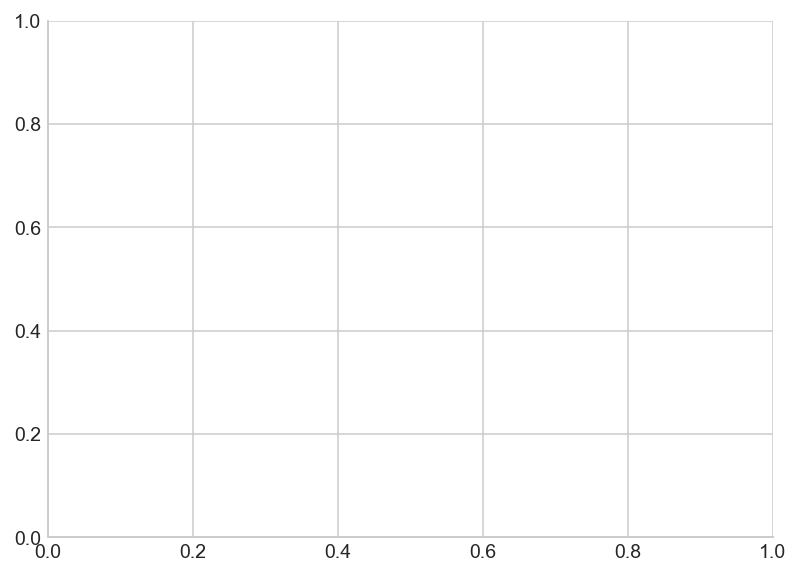

In [5]:
fig, ax = plt.subplots(figsize=(5.6, 4.0), constrained_layout=True)

# all settings
ax.scatter(
    combo_summary["avg_reasoning_tokens_mean"],
    combo_summary["avg_first_sentence_embedding_similarity_mean"],
    s=38,
    color="0.82",
    edgecolor="none",
    alpha=0.8,
    zorder=1,
)

# pareto frontier
frontier_plot = pareto.sort_values("avg_reasoning_tokens_mean").copy()
ax.plot(
    frontier_plot["avg_reasoning_tokens_mean"],
    frontier_plot["avg_first_sentence_embedding_similarity_mean"],
    color="black",
    linewidth=1.8,
    zorder=2,
)
ax.scatter(
    frontier_plot["avg_reasoning_tokens_mean"],
    frontier_plot["avg_first_sentence_embedding_similarity_mean"],
    s=46,
    color="black",
    zorder=3,
)

# selected point
ax.scatter(
    best_balanced["avg_reasoning_tokens_mean"],
    best_balanced["avg_first_sentence_embedding_similarity_mean"],
    s=170,
    marker="*",
    color="#C44E52",
    edgecolor="black",
    linewidth=0.8,
    zorder=4,
)

# minimal annotations
def annotate_point(row, text, dx=8, dy=8):
    ax.annotate(
        text,
        (row["avg_reasoning_tokens_mean"], row["avg_first_sentence_embedding_similarity_mean"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=9,
        ha="left",
        va="center",
        bbox={"boxstyle": "round,pad=0.2", "fc": "white", "ec": "0.8", "alpha": 0.95},
    )

annotate_point(best_balanced, "selected", dx=10, dy=10)
#annotate_point(shortest, "shortest", dx=10, dy=-12)
#annotate_point(most_diverse, "most diverse", dx=-40, dy=30)

ax.set_xlabel("Mean reasoning tokens")
ax.set_ylabel("Next sentence similarity")
#ax.set_title("Decoding tradeoff for localization data collection", pad=8)

ax.grid(True, alpha=0.2, linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.savefig("figure_decoding_tradeoff_clean.png")
plt.show()

In [6]:
temperatures = sorted(combo_summary["temperature"].unique())
top_ps = sorted(combo_summary["top_p"].unique())
repetition_penalties = sorted(combo_summary["repetition_penalty"].unique())


def heatmap_matrix(metric_col, repetition_penalty):
    sub = combo_summary[combo_summary["repetition_penalty"] == repetition_penalty]
    return (
        sub.pivot(index="temperature", columns="top_p", values=metric_col)
        .reindex(index=temperatures, columns=top_ps)
        .to_numpy(dtype=float)
    )


fig, axes = plt.subplots(2, 2, figsize=(12.2, 9.1), constrained_layout=True)
for row_idx, repetition_penalty in enumerate(repetition_penalties):
    token_matrix = heatmap_matrix("avg_reasoning_tokens_mean", repetition_penalty)
    sim_matrix = heatmap_matrix("avg_first_sentence_embedding_similarity_mean", repetition_penalty)
    for col_idx, (matrix, title, cmap, fmt) in enumerate(
        [
            (token_matrix, f"Avg reasoning tokens | rep={repetition_penalty:.1f}", "YlOrRd", "{:.0f}"),
            (
                sim_matrix,
                f"Avg first-sentence cosine | rep={repetition_penalty:.1f}",
                "viridis_r",
                "{:.3f}",
            ),
        ]
    ):
        ax = axes[row_idx, col_idx]
        im = ax.imshow(matrix, cmap=cmap, aspect="auto")
        ax.set_xticks(np.arange(len(top_ps)), labels=[f"{value:.1f}" for value in top_ps])
        ax.set_yticks(np.arange(len(temperatures)), labels=[f"{value:.1f}" for value in temperatures])
        ax.set_xlabel("top-p")
        ax.set_ylabel("temperature")
        ax.set_title(title)
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                ax.text(j, i, fmt.format(matrix[i, j]), ha="center", va="center", color="black", fontsize=9)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()

marginal_tables = {}
for param in ["temperature", "top_p", "repetition_penalty"]:
    marginal_tables[param] = (
        per_prefix.groupby(param)
        .agg(
            avg_reasoning_tokens=("avg_reasoning_tokens", "mean"),
            avg_first_sentence_embedding_similarity=("avg_first_sentence_embedding_similarity", "mean"),
            unique_first_sentence_fraction=("unique_first_sentence_fraction", "mean"),
        )
        .reset_index()
        .round(3)
    )

display(Markdown("### Marginal means by hyperparameter"))
for param in ["temperature", "top_p", "repetition_penalty"]:
    display(Markdown(f"#### By `{param}`"))
    display(marginal_tables[param])

contrast_specs = [
    {
        "comparison": "Raise top-p at temp=0.5, rep=1.2",
        "combo_a": (0.5, 0.5, 1.2),
        "combo_b": (0.5, 0.9, 1.2),
    },
    {
        "comparison": "Raise temperature at top-p=0.9, rep=1.2",
        "combo_a": (0.5, 0.9, 1.2),
        "combo_b": (0.9, 0.9, 1.2),
    },
    {
        "comparison": "Raise repetition penalty at temp=0.7, top-p=0.7",
        "combo_a": (0.7, 0.7, 1.1),
        "combo_b": (0.7, 0.7, 1.2),
    },
]

contrast_rows = []
for spec_idx, spec in enumerate(contrast_specs):
    token = paired_bootstrap_contrast(
        per_prefix,
        spec["combo_a"],
        spec["combo_b"],
        metric="avg_reasoning_tokens",
        seed=100 + spec_idx,
    )
    similarity = paired_bootstrap_contrast(
        per_prefix,
        spec["combo_a"],
        spec["combo_b"],
        metric="avg_first_sentence_embedding_similarity",
        seed=200 + spec_idx,
    )
    unique = paired_bootstrap_contrast(
        per_prefix,
        spec["combo_a"],
        spec["combo_b"],
        metric="unique_first_sentence_fraction",
        seed=300 + spec_idx,
    )
    contrast_rows.append(
        {
            "comparison": spec["comparison"],
            "combo_a": combo_label(spec["combo_a"]),
            "combo_b": combo_label(spec["combo_b"]),
            "token_diff_mean": token["mean_diff"],
            "token_diff_ci_low": token["ci_low"],
            "token_diff_ci_high": token["ci_high"],
            "similarity_diff_mean": similarity["mean_diff"],
            "similarity_diff_ci_low": similarity["ci_low"],
            "similarity_diff_ci_high": similarity["ci_high"],
            "unique_diff_mean": unique["mean_diff"],
            "unique_diff_ci_low": unique["ci_low"],
            "unique_diff_ci_high": unique["ci_high"],
            "n_prefixes": token["n_prefixes"],
        }
    )

contrasts = pd.DataFrame(contrast_rows).round(3)
display(Markdown("### Reportable paired contrasts"))
display(contrasts)


NameError: name 'combo_summary' is not defined

In [7]:
balanced_combo = combo_tuple(best_balanced)
env_rows = []
for env_name, env_df in per_prefix.groupby("env_name"):
    env_summary = summarize_combos(env_df)
    env_best = env_summary.nsmallest(1, "distance_to_ideal").iloc[0]
    env_ranked = env_summary.sort_values("distance_to_ideal").reset_index(drop=True).copy()
    env_ranked["rank"] = np.arange(1, len(env_ranked) + 1)
    balanced_rank = int(
        env_ranked[
            (env_ranked["temperature"] == balanced_combo[0])
            & (env_ranked["top_p"] == balanced_combo[1])
            & (env_ranked["repetition_penalty"] == balanced_combo[2])
        ]["rank"].iloc[0]
    )
    env_rows.append(
        {
            "env_name": env_name,
            "best_tradeoff_combo": combo_label(combo_tuple(env_best)),
            "best_tradeoff_tokens": float(env_best["avg_reasoning_tokens_mean"]),
            "best_tradeoff_similarity": float(env_best["avg_first_sentence_embedding_similarity_mean"]),
            "best_tradeoff_unique": float(env_best["unique_first_sentence_fraction_mean"]),
            "global_balanced_rank": balanced_rank,
            "global_balanced_tokens": float(
                env_ranked[
                    (env_ranked["temperature"] == balanced_combo[0])
                    & (env_ranked["top_p"] == balanced_combo[1])
                    & (env_ranked["repetition_penalty"] == balanced_combo[2])
                ]["avg_reasoning_tokens_mean"].iloc[0]
            ),
            "global_balanced_similarity": float(
                env_ranked[
                    (env_ranked["temperature"] == balanced_combo[0])
                    & (env_ranked["top_p"] == balanced_combo[1])
                    & (env_ranked["repetition_penalty"] == balanced_combo[2])
                ]["avg_first_sentence_embedding_similarity_mean"].iloc[0]
            ),
            "global_balanced_unique": float(
                env_ranked[
                    (env_ranked["temperature"] == balanced_combo[0])
                    & (env_ranked["top_p"] == balanced_combo[1])
                    & (env_ranked["repetition_penalty"] == balanced_combo[2])
                ]["unique_first_sentence_fraction_mean"].iloc[0]
            ),
        }
    )

env_tradeoff = pd.DataFrame(env_rows).sort_values(["global_balanced_rank", "env_name"]).reset_index(drop=True)
display(env_tradeoff.round(3))

fig, ax = plt.subplots(figsize=(8.8, 4.5), constrained_layout=True)
ax.bar(env_tradeoff["env_name"], env_tradeoff["global_balanced_rank"], color="#72B7B2")
ax.set_title("Rank of the global balanced choice within each environment")
ax.set_ylabel("Rank (1 = best tradeoff within env)")
ax.tick_params(axis="x", rotation=30)
for idx, value in enumerate(env_tradeoff["global_balanced_rank"]):
    ax.text(idx, value + 0.05, str(int(value)), ha="center", va="bottom", fontsize=9)
plt.show()


NameError: name 'combo_tuple' is not defined

In [8]:
baseline_combo = (0.5, 0.5, 1.1)
most_diverse_combo = combo_tuple(most_diverse)

example_shift_wide = per_prefix.pivot_table(
    index=["example_key", "env_name", "prefix_sentence_text"],
    columns=["temperature", "top_p", "repetition_penalty"],
    values=[
        "avg_reasoning_tokens",
        "avg_first_sentence_embedding_similarity",
        "unique_first_sentence_fraction",
    ],
)

interesting_examples = pd.DataFrame(
    {
        "example_key": example_shift_wide.index.get_level_values("example_key"),
        "env_name": example_shift_wide.index.get_level_values("env_name"),
        "delta_tokens_baseline_to_balanced": (
            example_shift_wide[("avg_reasoning_tokens",) + balanced_combo]
            - example_shift_wide[("avg_reasoning_tokens",) + baseline_combo]
        ).to_numpy(),
        "delta_similarity_baseline_to_balanced": (
            example_shift_wide[("avg_first_sentence_embedding_similarity",) + balanced_combo]
            - example_shift_wide[("avg_first_sentence_embedding_similarity",) + baseline_combo]
        ).to_numpy(),
        "delta_unique_baseline_to_balanced": (
            example_shift_wide[("unique_first_sentence_fraction",) + balanced_combo]
            - example_shift_wide[("unique_first_sentence_fraction",) + baseline_combo]
        ).to_numpy(),
    }
)

interesting_examples = interesting_examples.sort_values(
    ["delta_unique_baseline_to_balanced", "delta_similarity_baseline_to_balanced"],
    ascending=[False, True],
).head(12)
display(interesting_examples.round(3))

display_example_first_sentences(
    DEFAULT_QUAL_EXAMPLE_KEY,
    combos=[baseline_combo, balanced_combo, most_diverse_combo],
    top_k=6,
)


NameError: name 'combo_tuple' is not defined